In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (6, 3)

df = pd.read_csv("../transaction_data.csv")

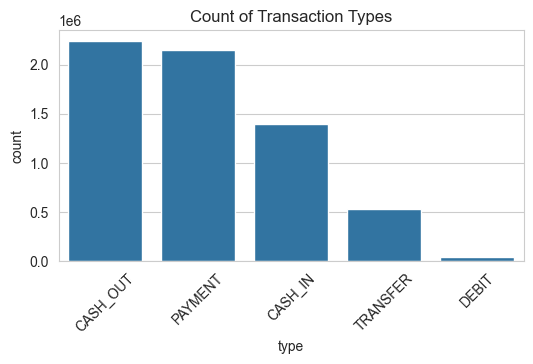

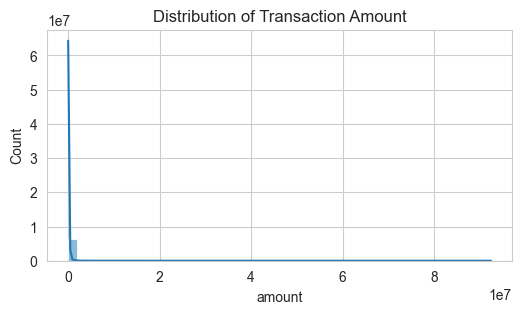

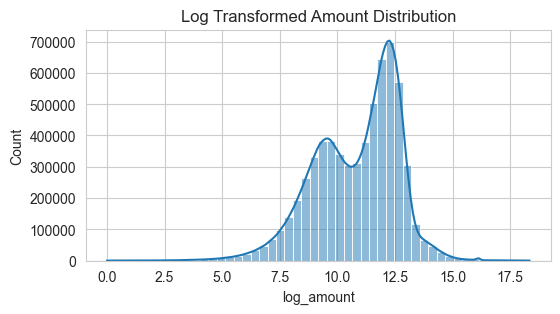

In [6]:
# Univariate analysis

# Transaction type frequency
df["type"].value_counts()

sns.countplot(x="type", data=df, order=df["type"].value_counts().index)
plt.title("Count of Transaction Types")
plt.xticks(rotation=45)
plt.show()

#  Amount distribution
sns.histplot(df["amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.show()

# Log amount distribution
df["log_amount"] = np.log1p(df["amount"])
sns.histplot(df["log_amount"], bins=50, kde=True)
plt.title("Log Transformed Amount Distribution")
plt.show()

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097
isFraud            0         1
type                          
CASH_IN   100.000000  0.000000
CASH_OUT   99.816045  0.183955
DEBIT     100.000000  0.000000
PAYMENT   100.000000  0.000000
TRANSFER   99.231201  0.768799


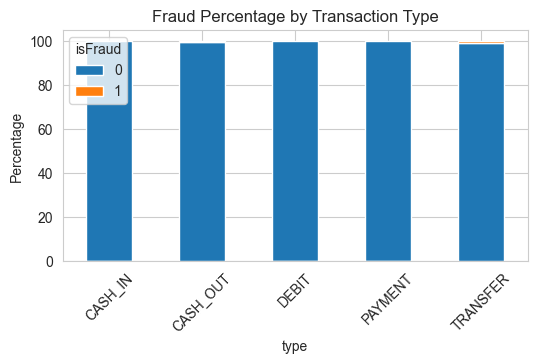

In [7]:
# Fraud vs Transaction Type
fraud_type = pd.crosstab(df["type"], df["isFraud"])
print(fraud_type)

fraud_type_norm = pd.crosstab(df["type"], df["isFraud"], normalize="index") * 100
print(fraud_type_norm)

fraud_type_norm.plot(kind="bar", stacked=True)
plt.title("Fraud Percentage by Transaction Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Fraud vs Amount
sns.boxplot(x="isFraud", y="amount", data=df)
plt.title("Fraud vs Transaction Amount")
plt.yscale("log")
plt.show()

df.groupby("isFraud")["amount"].describe()